# EDA 

In [30]:
import pandas as pd
import numpy as np

tickets_df = pd.read_csv("../references/Dataset/customer_support_tickets.csv")
customers_df = pd.read_csv("../references/Dataset/customers.csv")
products_df = pd.read_csv("../references/Dataset/product_usage.csv")

# Basic Dataset Understanding

## Customer Support Tickets csv

In [4]:
tickets_df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [5]:
print(f'Dataframe Shape {tickets_df.shape}')
print(f'Dataframe Types {tickets_df.dtypes}')

Dataframe Shape (8469, 16)
Dataframe Types Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 str
Time to Resolution                  str
Customer Satisfaction Rating    float64
dtype: object


In [6]:
tickets_df[tickets_df.duplicated()] 

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating


In [7]:
tickets_df.isna().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

## Customer csv

In [8]:
customers_df.head()

,Customer ID,Customer Name,Customer Email,Customer Age,Customer Gender,Industry,Region,Company Size,Plan Type,Account Created Date
0,CUST00001,Robert Downs,aanderson@example.com,42,Male,Technology,Europe,201-500,Standard,2020-12-20
1,CUST00002,Cesar Jensen,aanderson@example.net,35,Other,Retail,Asia-Pacific,201-500,Standard,2020-06-15
2,CUST00003,Angela Tran,aarnold@example.com,52,Other,Education,Asia-Pacific,1000+,Free,2020-10-24
3,CUST00004,Justin Estrada,aaron01@example.com,45,Female,Professional Services,Europe,11-50,Enterprise,2019-11-13
4,CUST00005,James Santos,aaron49@example.org,22,Other,Professional Services,Australia & New Zealand,501-1000,Standard,2019-04-21


In [9]:
print(f'Dataframe Shape {customers_df.shape}')
print(f'Dataframe Types {customers_df.dtypes}')

Dataframe Shape (8320, 10)
Dataframe Types Customer ID               str
Customer Name             str
Customer Email            str
Customer Age            int64
Customer Gender           str
Industry                  str
Region                    str
Company Size              str
Plan Type                 str
Account Created Date      str
dtype: object


In [10]:
customers_df[customers_df.duplicated()] 

,Customer ID,Customer Name,Customer Email,Customer Age,Customer Gender,Industry,Region,Company Size,Plan Type,Account Created Date


In [11]:
customers_df.isna().sum()

Customer ID             0
Customer Name           0
Customer Email          0
Customer Age            0
Customer Gender         0
Industry                0
Region                  0
Company Size            0
Plan Type               0
Account Created Date    0
dtype: int64

## Product Usage csv

In [12]:
products_df.head()

,Customer ID,Product,Month,Active Days,Sessions,Product Actions,Collaborators,Integrations Used
0,CUST00001,Loom,2023-01,3,7,49,12,3
1,CUST00001,Loom,2023-02,4,7,22,4,4
2,CUST00001,Loom,2023-03,5,10,37,5,3
3,CUST00001,Loom,2023-04,4,7,47,12,1
4,CUST00001,Loom,2023-05,5,10,34,4,3


In [13]:
print(f'Dataframe Shape {products_df.shape}')
print(f'Dataframe Types {products_df.dtypes}')

Dataframe Shape (42210, 8)
Dataframe Types Customer ID            str
Product                str
Month                  str
Active Days          int64
Sessions             int64
Product Actions      int64
Collaborators        int64
Integrations Used    int64
dtype: object


In [14]:
products_df[products_df.duplicated()] 

,Customer ID,Product,Month,Active Days,Sessions,Product Actions,Collaborators,Integrations Used


In [15]:
products_df.isna().sum()

Customer ID          0
Product              0
Month                0
Active Days          0
Sessions             0
Product Actions      0
Collaborators        0
Integrations Used    0
dtype: int64

# Joining Tables Together

We can notice that all three datasets have a customer ID. As such, we will join all three tables on the customer ID to get a better sense of the customer's product usage. First, we will reformat the products datafram such that the months are arranged as columns instead of rows

In [32]:
total_months = products_df['Month'].nunique()

month_counts = products_df.groupby(["Customer ID", "Product"])["Month"].nunique().reset_index()
month_counts.columns = ["Customer ID", "Product", "Month Count"]

incomplete_customers = month_counts[month_counts["Month Count"] < total_months] 
print(incomplete_customers)

product_counts = products_df.groupby(["Customer ID"])["Product"].nunique().reset_index()
product_counts.columns = ["Customer ID", "Product Count"]

multi_product_customers = product_counts[product_counts["Product Count"] > 1] 
print(multi_product_customers)

Empty DataFrame
Columns: [Customer ID, Product, Month Count]
Index: []
     Customer ID  Product Count
324    CUST00325              2
479    CUST00480              2
480    CUST00481              3
482    CUST00483              2
646    CUST00647              2
...          ...            ...
8152   CUST08153              2
8198   CUST08199              2
8234   CUST08235              2
8272   CUST08273              2
8289   CUST08290              2

[118 rows x 2 columns]


In [33]:
def customer_usage_trends(usage: pd.DataFrame) -> pd.DataFrame:
    ENGAGEMENT_METRICS = ["Active Days", "Sessions", "Product Actions"]
    EMBEDDEDNESS_WEIGHTS = {"Collaborators": 1, "Integrations Used": 2}

    metrics = ENGAGEMENT_METRICS + list(EMBEDDEDNESS_WEIGHTS)

    # Aggregate across products per customer per month so multi-product accounts have 1 row per month
    monthly = usage.groupby(["Customer ID", "Month"])[metrics].sum().reset_index()

    def slope(group: pd.DataFrame) -> pd.Series:
        group = group.sort_values("Month")
        x = np.arange(len(group))
        out = {}
        for m in metrics:
            y = group[m].values.astype(float)
            out[f"{m} Slope"] = np.polyfit(x, y, 1)[0] if len(y) >= 2 else np.nan
            out[f"{m} Pct Change"] = (
                (y[-1] - y[0]) / y[0] * 100 if y[0] != 0 else np.nan
            )
        return pd.Series(out)

    return monthly.groupby("Customer ID").apply(slope, include_groups=False).reset_index()

In [34]:
usage_trends = customer_usage_trends(products_df)
combined_product_df = pd.merge(customers_df, usage_trends, on='Customer ID', how='left')
combined_df = pd.merge(tickets_df, combined_product_df, on='Customer Email', how='left')

In [35]:
combined_df.head()

,Ticket ID,Customer Name_x,Customer Email,Customer Age_x,Customer Gender_x,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,...,Active Days Slope,Active Days Pct Change,Sessions Slope,Sessions Pct Change,Product Actions Slope,Product Actions Pct Change,Collaborators Slope,Collaborators Pct Change,Integrations Used Slope,Integrations Used Pct Change
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,...,0.1,20.000000,0.2,20.0,1.4,37.777778,-1.4,-30.000000,-0.2,-100.000000
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,...,0.5,100.000000,0.8,60.0,6.0,69.565217,1.5,100.000000,0.3,33.333333
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,...,0.6,16.666667,0.3,12.5,3.3,70.329670,0.6,50.000000,-0.2,33.333333
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,...,-0.4,-25.000000,-0.9,-37.5,-5.9,-24.528302,-0.1,0.000000,0.4,150.000000
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,...,-0.2,0.000000,-0.6,-12.5,-3.0,-1.680672,0.5,27.272727,0.4,16.666667


In [36]:
print(f'Dataframe Shape {combined_df.shape}')
print(f'Dataframe Types {combined_df.dtypes}')

Dataframe Shape (8469, 35)
Dataframe Types Ticket ID                         int64
Customer Name_x                     str
Customer Email                      str
Customer Age_x                    int64
Customer Gender_x                   str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 str
Time to Resolution                  str
Customer Satisfaction Rating    float64
Customer ID                         str
Customer Name_y                     str
Customer Age_y                    int64
Customer Gender_y                   str
Industry                            str
Region                              str
Company Size                        str
Plan Type                           s

In [37]:
combined_df[combined_df.duplicated()] 

,Ticket ID,Customer Name_x,Customer Email,Customer Age_x,Customer Gender_x,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,...,Active Days Slope,Active Days Pct Change,Sessions Slope,Sessions Pct Change,Product Actions Slope,Product Actions Pct Change,Collaborators Slope,Collaborators Pct Change,Integrations Used Slope,Integrations Used Pct Change


In [38]:
combined_df.isna().sum()

Ticket ID                          0
Customer Name_x                    0
Customer Email                     0
Customer Age_x                     0
Customer Gender_x                  0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
Customer ID                        0
Customer Name_y                    0
Customer Age_y                     0
Customer Gender_y                  0
Industry                           0
Region                             0
Company Size                       0
Plan Type                          0
Account Created Date               0
Active Days Slope                  0
Active Days Pct Change             0
S

We can see that there are some duplicated variables like ```Customer Name_x```, ```Customer Name_y``` etc because the same column existed in two different dataframes. Thus, we can just drop one of them. 

In [39]:
combined_df = combined_df.drop(columns=["Customer Name_x", "Customer Age_x", "Customer Gender_x"])
combined_df = combined_df.rename(columns={"Customer Name_y": "Customer Name", "Customer Age_y": "Customer Age", "Customer Gender_y": "Customer Gender"})

# Cleaning the Data

In [41]:
combined_df["First Response Time"] = pd.to_datetime(
    combined_df["First Response Time"], format="%d-%m-%Y %H:%M", errors="coerce"
)
combined_df["Time to Resolution"] = pd.to_datetime(
    combined_df["Time to Resolution"], format="%d-%m-%Y %H:%M", errors="coerce"
)

In [44]:
def ticketStage(row):
    if pd.isna(row["First Response Time"]):
        return "Not Started"
    elif pd.isna(row["Time to Resolution"]):
        return "In Progress (awaiting resolution)"
    else:
        return "Resolved"

combined_df["Ticket Stage"] = combined_df.apply(ticketStage, axis=1)

We can note that we are not given the starting time for when a ticket begins to get worked on by the team. Thus, we can just calculate the time taken to resolve the resolved tickets and drop the First respones times and Time to Resolution columns.

In [45]:
combined_df["Response to Resolution Hours"] = (
    combined_df["Time to Resolution"] - combined_df["First Response Time"]
).dt.total_seconds() / 3600

# Fix synthetic timestamp artifact: resolution recorded before first response is set to NaN
combined_df.loc[combined_df["Response to Resolution Hours"] < 0, "Response to Resolution Hours"] = np.nan

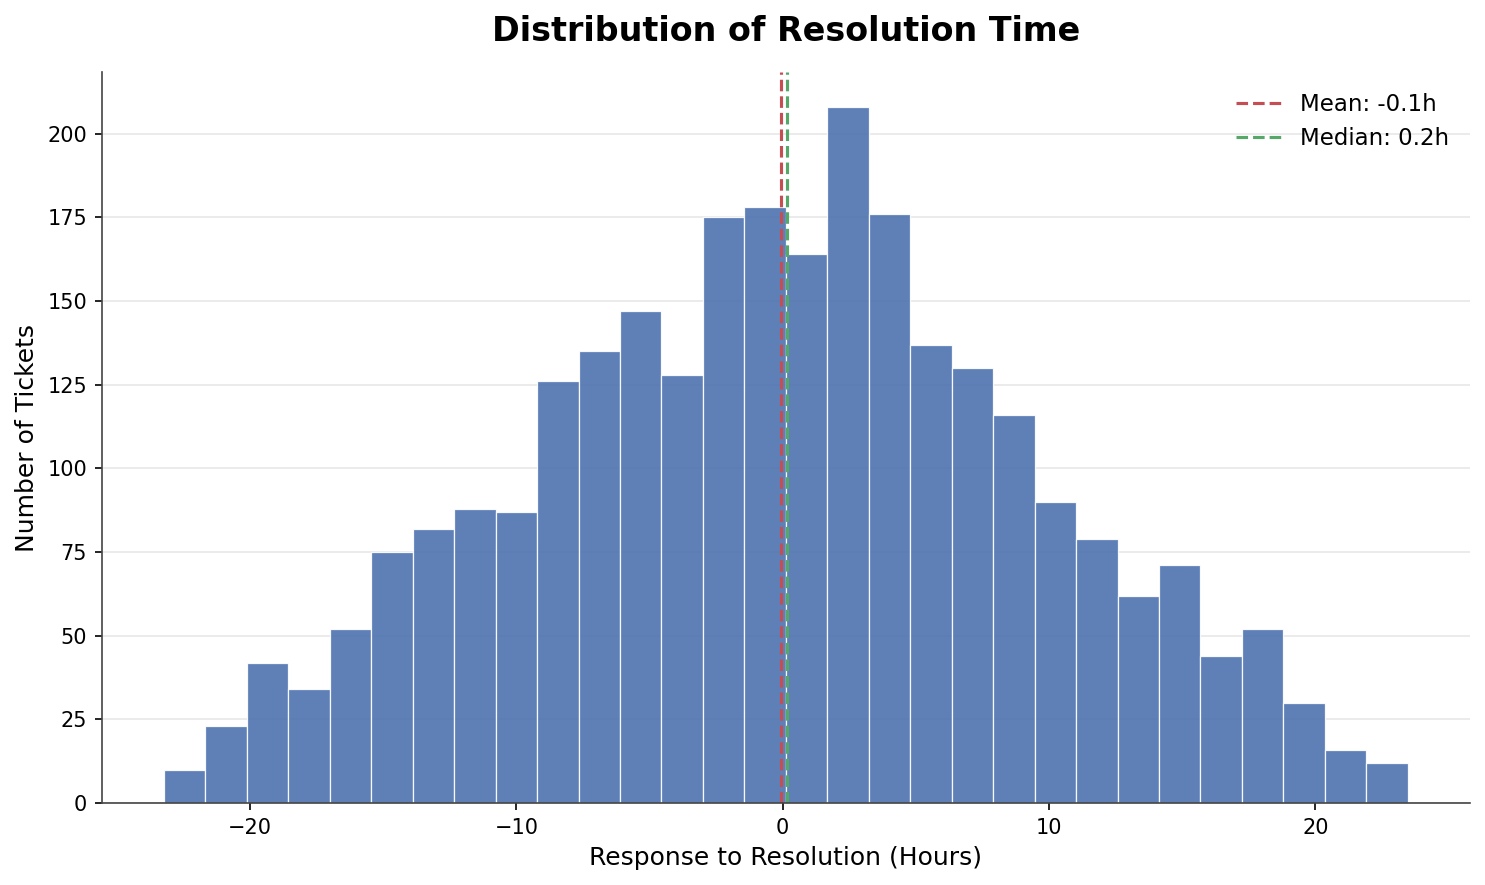

In [64]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

resolvedDf = combined_df[combined_df["Ticket Stage"] == "Resolved"]

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)

data = resolvedDf["Response to Resolution Hours"].dropna()

ax.hist(
    data,
    bins=30,
    color="#4C72B0",
    edgecolor="white",
    linewidth=0.6,
    alpha=0.9
)

# Reference lines
mean_val = data.mean()
median_val = data.median()
ax.axvline(mean_val, color="#C44E52", linestyle="--", linewidth=1.5, label=f"Mean: {mean_val:.1f}h")
ax.axvline(median_val, color="#55A868", linestyle="--", linewidth=1.5, label=f"Median: {median_val:.1f}h")

# Titles and labels
ax.set_title("Distribution of Resolution Time", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Response to Resolution (Hours)", fontsize=12)
ax.set_ylabel("Number of Tickets", fontsize=12)

# Clean up spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#444444")
ax.spines["bottom"].set_color("#444444")

# Gridlines behind bars, subtle
ax.grid(axis="y", linestyle="-", alpha=0.3)
ax.set_axisbelow(True)

# Thousands separators on y-axis if counts are large
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("resolution_time_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

However, here we note that a lot of the resolution times actually come before the first response time and it's in the shape of a normal distribution. This indicates that this data might be randomly generated and impossible to use as it holds invalid values. 

In [47]:
combined_df['Ticket Priority'].nunique()

4

In [48]:
priorityMap = {"Low": 0, "Medium": 1, "High": 2, "Critical": 3}
combined_df["Ticket Priority Coded"] = combined_df["Ticket Priority"].map(priorityMap)

In [49]:
combined_df["Has Satisfaction Rating"] = combined_df["Customer Satisfaction Rating"].notna()

In [ ]:
combined_df.groupby("Ticket Priority")["Customer Satisfaction Rating"].mean()
combined_df.groupby("Plan Type")["Customer Satisfaction Rating"].mean()

Ticket Priority
Critical    2.958678
High        2.982979
Low         3.052795
Medium      2.976945
Name: Customer Satisfaction Rating, dtype: float64

# Univariate Analysis

In [52]:
numericCols = combined_df.select_dtypes(include="number").columns
categoricalCols = combined_df.select_dtypes(include="object").columns

for col in numericCols:
    print(combined_df[col].describe())
    print()

for col in categoricalCols:
    print(combined_df[col].value_counts(normalize=True).head(10))
    print()

count    8469.000000
mean     4235.000000
std      2444.934048
min         1.000000
25%      2118.000000
50%      4235.000000
75%      6352.000000
max      8469.000000
Name: Ticket ID, dtype: float64

count    2769.000000
mean        2.991333
std         1.407016
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Customer Satisfaction Rating, dtype: float64

count    8469.000000
mean       44.001771
std        15.278060
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Customer Age, dtype: float64

count    8.469000e+03
mean    -1.445881e-02
std      6.602500e-01
min     -3.300000e+00
25%     -4.000000e-01
50%     -3.243169e-16
75%      4.000000e-01
max      3.500000e+00
Name: Active Days Slope, dtype: float64

count    8469.000000
mean       10.656092
std        61.881536
min       -92.857143
25%       -23.076923
50%         0.000000
75%        27.272727
max       8

/var/folders/sv/sgr0jq7s5zdd9_pb9fntsc8r0000gn/T/ipykernel_89362/2742159883.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricalCols = combined_df.select_dtypes(include="object").columns


## Checking whether ticket count or resolution status affects usage

In [53]:
# ticket count per customer
ticketCounts = combined_df.groupby("Customer ID")["Ticket ID"].nunique().reset_index()
ticketCounts.columns = ["Customer ID", "Ticket Count"]

# merge onto a customer-level table that already has the usage slopes
# (assuming combined_product_df is your customer-level table with usage_trends already merged in)
riskCheckDf = combined_product_df.merge(ticketCounts, on="Customer ID", how="left")
riskCheckDf["Ticket Count"] = riskCheckDf["Ticket Count"].fillna(0)

# correlation between ticket volume and usage trend
print(riskCheckDf[["Ticket Count", "Active Days Slope", "Sessions Slope", "Product Actions Slope"]].corr())

# also worth checking as a groupby — does high ticket volume line up with negative slopes?
print(riskCheckDf.groupby("Ticket Count")["Active Days Slope"].mean())

                       Ticket Count  Active Days Slope  Sessions Slope  \
Ticket Count               1.000000          -0.008606       -0.006335   
Active Days Slope         -0.008606           1.000000        0.759826   
Sessions Slope            -0.006335           0.759826        1.000000   
Product Actions Slope     -0.010060           0.373685        0.502831   

                       Product Actions Slope  
Ticket Count                       -0.010060  
Active Days Slope                   0.373685  
Sessions Slope                      0.502831  
Product Actions Slope               1.000000  
Ticket Count
1   -0.013055
2   -0.046912
3    0.116324
4   -0.681818
Name: Active Days Slope, dtype: float64


In [54]:
# does this customer have ANY unresolved ticket (Not Started or In Progress)?
unresolvedFlag = (
    combined_df.groupby("Customer ID")["Ticket Stage"]
    .apply(lambda stages: (stages != "Resolved").any())
    .reset_index()
)
unresolvedFlag.columns = ["Customer ID", "Has Unresolved Ticket"]

riskCheckDf = riskCheckDf.merge(unresolvedFlag, on="Customer ID", how="left")

# compare average usage slope for customers WITH vs WITHOUT an unresolved ticket
print(riskCheckDf.groupby("Has Unresolved Ticket")["Active Days Slope"].mean())
print(riskCheckDf.groupby("Has Unresolved Ticket")["Sessions Slope"].mean())
print(riskCheckDf.groupby("Has Unresolved Ticket")["Product Actions Slope"].mean())

Has Unresolved Ticket
False   -0.031746
True    -0.005054
Name: Active Days Slope, dtype: float64
Has Unresolved Ticket
False   -0.067982
True    -0.026880
Name: Sessions Slope, dtype: float64
Has Unresolved Ticket
False   -0.690900
True    -0.200299
Name: Product Actions Slope, dtype: float64


In [55]:
riskCheckDf["Has Unresolved Ticket"].value_counts()
riskCheckDf["Ticket Count"].describe()

count    8320.000000
mean        1.017909
std         0.143091
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         4.000000
Name: Ticket Count, dtype: float64

## Checking Ticket Type and Ticket Subject

In [56]:
print(combined_df["Ticket Type"].value_counts(normalize=True))
print()
print(combined_df["Ticket Subject"].value_counts(normalize=True))

Ticket Type
Refund request          0.206872
Technical issue         0.206282
Cancellation request    0.200142
Product inquiry         0.193765
Billing inquiry         0.192939
Name: proportion, dtype: float64

Ticket Subject
Refund request                0.068013
Software bug                  0.067777
Product compatibility         0.066950
Email delivery problem        0.066242
Device compatibility issue    0.064588
Loading issue                 0.063998
Network problem               0.063644
Installation support          0.062581
Product setup                 0.062463
Payment issue                 0.062109
Product recommendation        0.061046
Account access                0.060102
Integration                   0.058567
Data loss                     0.057976
Cancellation request          0.057504
Display issue                 0.056441
Name: proportion, dtype: float64


In [57]:
# most common Ticket Type per customer
mostCommonType = (
    combined_df.groupby("Customer ID")["Ticket Type"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
)
mostCommonType.columns = ["Customer ID", "Most Common Ticket Type"]

riskCheckDf = riskCheckDf.merge(mostCommonType, on="Customer ID", how="left")

print(riskCheckDf.groupby("Most Common Ticket Type")["Active Days Slope"].mean())
print(riskCheckDf.groupby("Most Common Ticket Type")["Sessions Slope"].mean())
print(riskCheckDf.groupby("Most Common Ticket Type")["Product Actions Slope"].mean())

# also check group sizes — small groups make the mean unreliable
print(riskCheckDf["Most Common Ticket Type"].value_counts())

Most Common Ticket Type
Billing inquiry        -0.028100
Cancellation request   -0.021010
Product inquiry         0.008008
Refund request         -0.036325
Technical issue         0.009712
Name: Active Days Slope, dtype: float64
Most Common Ticket Type
Billing inquiry        -0.090408
Cancellation request   -0.050153
Product inquiry        -0.004708
Refund request         -0.058462
Technical issue         0.002744
Name: Sessions Slope, dtype: float64
Most Common Ticket Type
Billing inquiry        -0.463804
Cancellation request   -0.275279
Product inquiry        -0.063979
Refund request         -0.742759
Technical issue        -0.232316
Name: Product Actions Slope, dtype: float64
Most Common Ticket Type
Refund request          1711
Technical issue         1692
Cancellation request    1677
Billing inquiry         1623
Product inquiry         1617
Name: count, dtype: int64


In [58]:
from scipy import stats
groups = [g["Product Actions Slope"].dropna() for _, g in riskCheckDf.groupby("Most Common Ticket Type")]
print(stats.f_oneway(*groups))

F_onewayResult(statistic=np.float64(0.8307126755130859), pvalue=np.float64(0.5053616117559132))


In [61]:
mostCommonSubject = (
    combined_df.groupby("Customer ID")["Ticket Subject"]
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
)
mostCommonSubject.columns = ["Customer ID", "Most Common Ticket Subject"]

riskCheckDf = riskCheckDf.merge(mostCommonSubject, on="Customer ID", how="left")

print(riskCheckDf.groupby("Most Common Ticket Subject")["Active Days Slope"].mean())
print(riskCheckDf["Most Common Ticket Subject"].value_counts())

Most Common Ticket Subject
Account access                0.008980
Cancellation request         -0.022563
Data loss                    -0.016745
Device compatibility issue   -0.031465
Display issue                -0.033912
Email delivery problem       -0.041484
Installation support         -0.024834
Integration                   0.040299
Loading issue                -0.048139
Network problem              -0.035972
Payment issue                 0.007915
Product compatibility        -0.022143
Product recommendation       -0.012679
Product setup                 0.000256
Refund request                0.016631
Software bug                 -0.000729
Name: Active Days Slope, dtype: float64
Most Common Ticket Subject
Refund request                559
Software bug                  557
Email delivery problem        551
Product compatibility         550
Device compatibility issue    544
Loading issue                 533
Network problem               526
Product setup                 521
Payment is

In [62]:
groups = [g["Product Actions Slope"].dropna() for _, g in riskCheckDf.groupby("Most Common Ticket Subject")]
print(stats.f_oneway(*groups))

F_onewayResult(statistic=np.float64(1.11703527960955), pvalue=np.float64(0.3339204265332907))


In [63]:
from pathlib import Path
out_path = Path("../references/Dataset/combined_dataset.csv") if Path("../references/Dataset").exists() else Path("references/Dataset/combined_dataset.csv")
combined_df.to_csv(out_path, index=False)
print(f"Saved {len(combined_df)} rows to {out_path}")

# Charts: The Ticket Table Doesn't Move With Anything Real

The stats above (flat ticket counts across usage buckets, flat ANOVA p-values across ticket type/subject, resolution timestamps that predate the first response) already establish this numerically. These charts make it visible, ending with the specific case that matters most for a churn story: customers who filed a **cancellation-request ticket**, split by whether that ticket was ever resolved.

In [69]:
import textwrap

# shared chart styling — reused by every chart in this section
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"
SEQ_BLUE = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]  # light -> dark, ordered/sequential use only
SERIES_BLUE = "#2a78d6"
SERIES_ORANGE = "#eb6834"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "font.size": 11,
    "axes.grid": True,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": True,
})


def style_axes(ax):
    ax.grid(axis="y", zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)


def wrapped_title(ax, title, subtitle, title_width=58, subtitle_width=78):
    ax.set_title("\n".join(textwrap.wrap(title, title_width)),
                 fontsize=13, color=INK_PRIMARY, loc="left", pad=34, fontweight="bold")
    ax.text(0, 1.06, "\n".join(textwrap.wrap(subtitle, subtitle_width)),
            fontsize=9.5, color=INK_SECONDARY, transform=ax.transAxes, va="bottom")

## 1. Ticket volume doesn't track engagement level

**Updated from the original version of this chart**, which split customers into quartiles of `Product Actions Slope`. `analysis/reliability_checks.py` ran a permutation test on that slope afterward and showed it's statistically indistinguishable from noise — shuffling a customer's own 5 months into random order barely changes the slope distribution (SD ratio ≈ 1.0), and a customer trending up early doesn't keep trending up later (negative split-half correlation, i.e. mean reversion, not a trajectory). So "Q1: declining fastest" wasn't a real cohort, just the quarter of customers whose 5 noisy points happened to lean down.

This version instead splits customers into quartiles of `Engagement Percentile` — peer-relative usage level within Plan Type × Primary Product, the same validated signal (real, stable: 0.82 month-to-month persistence) that the actual Risk Score is built on. Same conclusion, now resting on a feature that's real.

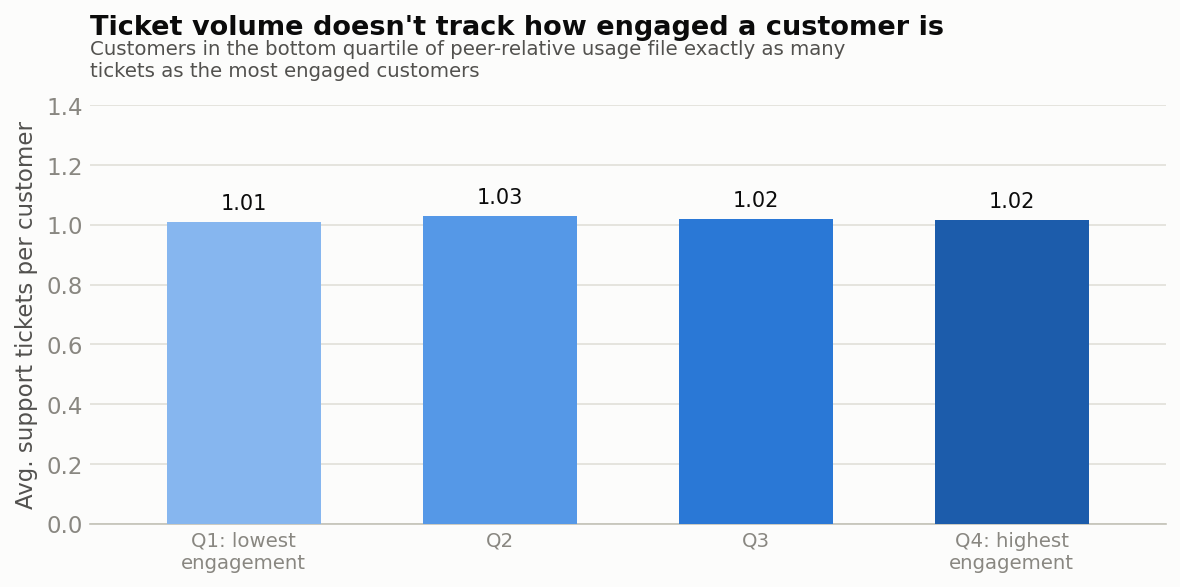

In [70]:
usageAvg = products_df.groupby("Customer ID")[["Active Days", "Sessions", "Product Actions"]].mean().reset_index()
productTotals = products_df.groupby(["Customer ID", "Product"])["Active Days"].sum().reset_index()
primaryProduct = productTotals.loc[productTotals.groupby("Customer ID")["Active Days"].idxmax(), ["Customer ID", "Product"]]
primaryProduct.columns = ["Customer ID", "Primary Product"]

engagementDf = customers_df.merge(usageAvg, on="Customer ID").merge(primaryProduct, on="Customer ID")

def normalise(col):
    filled = col.fillna(col.median())
    span = filled.max() - filled.min()
    return (filled - filled.min()) / span if span else filled * 0

engagementDf["Engagement Composite"] = pd.concat(
    [normalise(engagementDf[m]) for m in ["Active Days", "Sessions", "Product Actions"]], axis=1
).mean(axis=1)
# Peer-relative: rank within Plan Type x Primary Product, since those are the two
# real drivers of usage baseline (Free vs Enterprise, Jira vs Loom) -- comparing a
# customer only to their own peers avoids penalising naturally lower-touch tiers/products.
engagementDf["Engagement Percentile"] = engagementDf.groupby(
    ["Plan Type", "Primary Product"], observed=True
)["Engagement Composite"].rank(pct=True) * 100

engagementDf = engagementDf.merge(riskCheckDf[["Customer ID", "Ticket Count"]], on="Customer ID", how="left")

engagementDf["Engagement Quartile"] = pd.qcut(
    engagementDf["Engagement Percentile"], 4,
    labels=["Q1: lowest\nengagement", "Q2", "Q3", "Q4: highest\nengagement"],
)
ticketVolByQuartile = engagementDf.groupby("Engagement Quartile", observed=True)["Ticket Count"].mean()

fig, ax = plt.subplots(figsize=(8, 4.6), dpi=150)
bars = ax.bar(range(len(ticketVolByQuartile)), ticketVolByQuartile.values, color=SEQ_BLUE, width=0.6, zorder=3)
for b, v in zip(bars, ticketVolByQuartile.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.03, f"{v:.2f}", ha="center", va="bottom", fontsize=10, color=INK_PRIMARY)

ax.set_ylim(0, 1.4)
ax.set_ylabel("Avg. support tickets per customer")
wrapped_title(
    ax,
    "Ticket volume doesn't track how engaged a customer is",
    "Customers in the bottom quartile of peer-relative usage file exactly as many tickets as the most engaged customers",
)
ax.set_xticks(range(len(ticketVolByQuartile)))
ax.set_xticklabels(ticketVolByQuartile.index, fontsize=9.5)
ax.set_xlim(-0.6, len(ticketVolByQuartile) - 0.4)
style_axes(ax)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

## 2. Satisfaction score doesn't track ticket priority

If `Customer Satisfaction Rating` meant anything, a badly-handled Critical ticket should score worse than a quickly-handled Low one. It doesn't move at all.

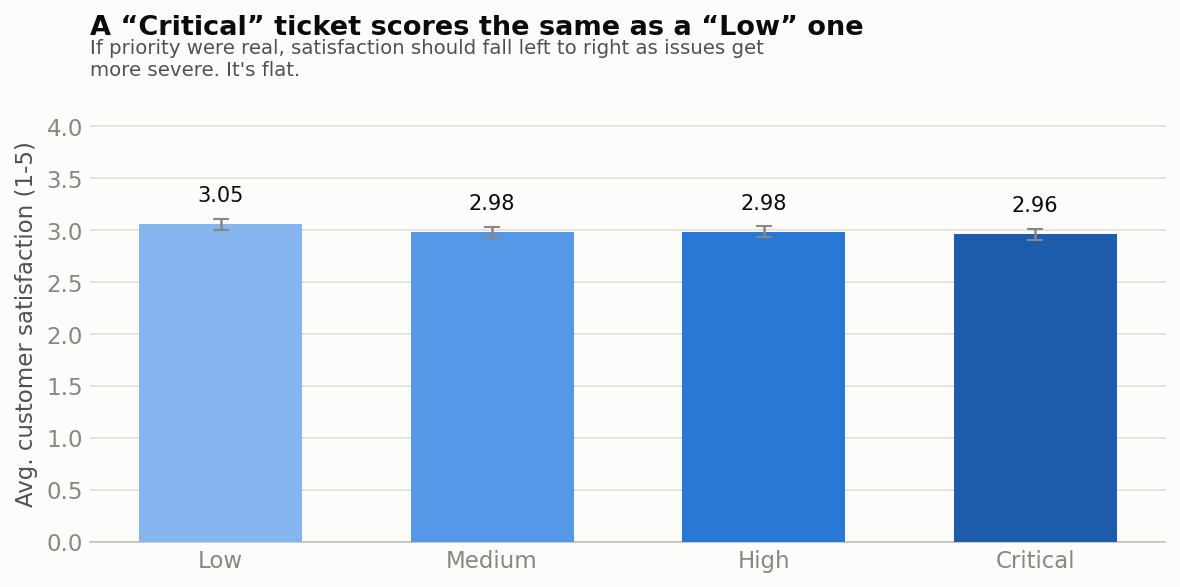

In [67]:
priorityOrder = ["Low", "Medium", "High", "Critical"]
satByPriority = (
    tickets_df.dropna(subset=["Customer Satisfaction Rating"])
    .groupby("Ticket Priority")["Customer Satisfaction Rating"]
    .agg(["mean", "sem"])
    .reindex(priorityOrder)
)

fig, ax = plt.subplots(figsize=(8, 4.6), dpi=150)
bars = ax.bar(priorityOrder, satByPriority["mean"], yerr=satByPriority["sem"], capsize=4,
              color=SEQ_BLUE, width=0.6, zorder=3,
              error_kw={"ecolor": INK_MUTED, "elinewidth": 1.2})
for i, v in enumerate(satByPriority["mean"]):
    ax.text(i, v + 0.18, f"{v:.2f}", ha="center", va="bottom", fontsize=10, color=INK_PRIMARY)

ax.set_ylim(0, 4.2)
ax.set_ylabel("Avg. customer satisfaction (1-5)")
wrapped_title(
    ax,
    "A “Critical” ticket scores the same as a “Low” one",
    "If priority were real, satisfaction should fall left to right as issues get more severe. It's flat.",
)
style_axes(ax)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

## 3. Headline case: resolving a cancellation ticket doesn't change the customer's behaviour

Take every customer who filed a `Cancellation request` ticket and split them by whether that ticket was ever resolved (`Ticket Stage == "Resolved"`, i.e. Ticket Status `Closed`) vs. left open (`Open` / `Pending Customer Response`). Then look at their actual monthly usage — not a slope, the real `Active Days` numbers from `product_usage.csv` — month by month across Jan-May 2023. If resolving the complaint meant anything, the resolved group should recover relative to the unresolved group. It doesn't: both drift down in parallel, and a per-month t-test never gets close to significance.

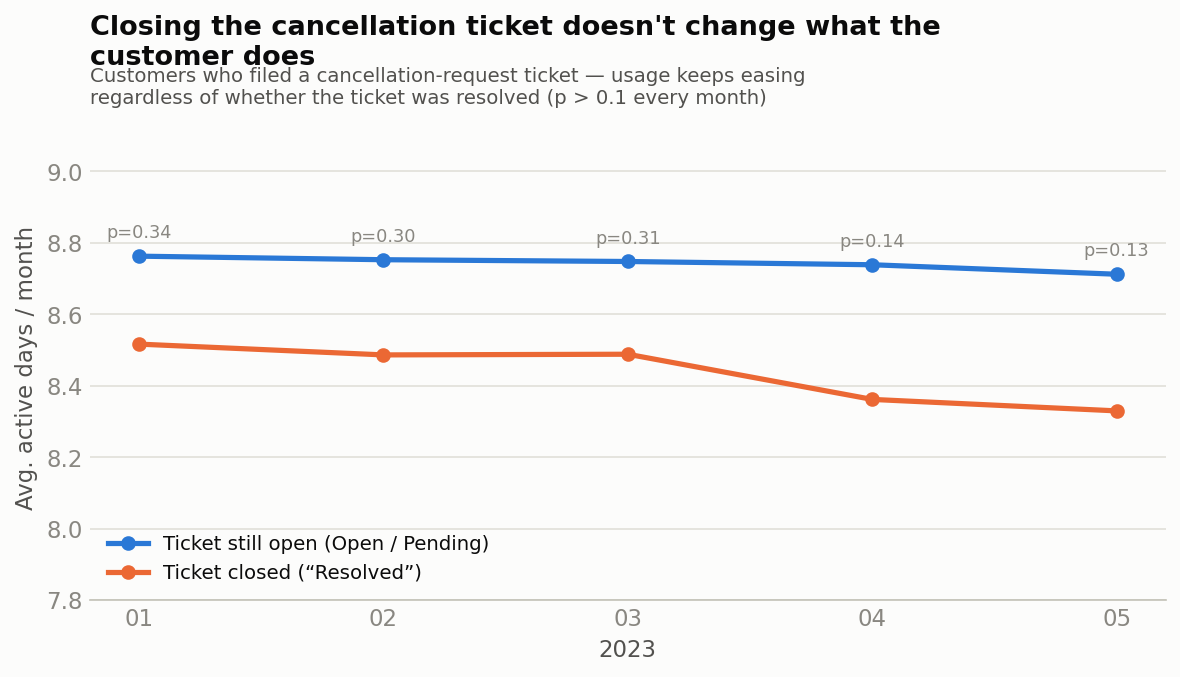

In [68]:
cancelTickets = combined_df.loc[combined_df["Ticket Type"] == "Cancellation request", ["Customer ID", "Ticket Stage"]].drop_duplicates("Customer ID")
cancelTickets["Resolution Status"] = np.where(cancelTickets["Ticket Stage"] == "Resolved", "Resolved", "Unresolved")

usageForCancelCustomers = products_df.merge(cancelTickets, on="Customer ID", how="inner")
monthlyUsageByResolution = usageForCancelCustomers.groupby(["Month", "Resolution Status"])["Active Days"].mean().unstack("Resolution Status")

monthlyPValues = {}
for m in monthlyUsageByResolution.index:
    resolvedVals = usageForCancelCustomers.loc[
        (usageForCancelCustomers.Month == m) & (usageForCancelCustomers["Resolution Status"] == "Resolved"), "Active Days"
    ]
    unresolvedVals = usageForCancelCustomers.loc[
        (usageForCancelCustomers.Month == m) & (usageForCancelCustomers["Resolution Status"] == "Unresolved"), "Active Days"
    ]
    monthlyPValues[m] = stats.ttest_ind(resolvedVals, unresolvedVals, equal_var=False).pvalue

fig, ax = plt.subplots(figsize=(8, 5.4), dpi=150)
x = range(len(monthlyUsageByResolution.index))
ax.plot(x, monthlyUsageByResolution["Unresolved"], color=SERIES_BLUE, linewidth=2.5, marker="o", markersize=6, zorder=4, label="Ticket still open (Open / Pending)")
ax.plot(x, monthlyUsageByResolution["Resolved"], color=SERIES_ORANGE, linewidth=2.5, marker="o", markersize=6, zorder=4, label="Ticket closed (“Resolved”)")

for xi, m in zip(x, monthlyUsageByResolution.index):
    ax.text(xi, max(monthlyUsageByResolution.loc[m]) + 0.05, f"p={monthlyPValues[m]:.2f}", ha="center", fontsize=8.5, color=INK_MUTED)

ax.set_xticks(list(x))
ax.set_xticklabels([m.replace("2023-", "") for m in monthlyUsageByResolution.index])
ax.set_ylim(7.8, 9.1)
ax.set_ylabel("Avg. active days / month")
ax.set_xlabel("2023")
wrapped_title(
    ax,
    "Closing the cancellation ticket doesn't change what the customer does",
    "Customers who filed a cancellation-request ticket — usage keeps easing regardless of whether the ticket was resolved (p > 0.1 every month)",
)
ax.legend(frameon=False, loc="lower left", fontsize=9.5)
style_axes(ax)
fig.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

## 4. Ticket Type carries no information about engagement at all — the full distribution, not just the average

Every chart so far compared **averages** across categories (average ticket count, average satisfaction). That leaves a gap: two groups can have the same average and still be genuinely different — one could be a tight cluster of "medium" customers, the other a 50/50 mix of "very high" and "very low." A histogram closes that gap by showing the whole shape, not just where its center sits.

**What's being plotted:** for each `Ticket Type`, the full distribution of `Engagement Percentile` (the same peer-relative usage-level feature from chart 1) across every customer who filed that ticket type.

**Why the dashed line is the key to reading it:** `Engagement Percentile` is a percentile rank, so *by definition*, if you pool every customer in the dataset, it is perfectly uniform from 0 to 100 — equal numbers of customers at every level, purely by construction. That gives us a known, exact prediction to test against: if `Ticket Type` has **zero** relationship to engagement, then restricting to just the "Cancellation request" customers (or any other single type) should *still* look uniform, because slicing a uniform distribution by something unrelated to it produces another uniform distribution of the same shape, just smaller. The dashed line marks that exact predicted height (`number of customers in this category ÷ 10 bins`).

**What we're actually checking, in plain terms:** if filing a cancellation ticket were a sign of low engagement, that panel's bars would lean left — piled up near 0 and thin near 100. What we see instead is five panels that all look like random noise scattered evenly around the dashed line, with no lean in either direction. An ANOVA across all five ticket types (`Engagement Percentile` as the outcome) gives p = 0.636 — nowhere close to significant. Repeating the same test for `Ticket Channel` (p = 0.352) and `Ticket Status` (p = 0.688) gives the identical result.

**The takeaway to say out loud:** it's not just that the *average* engagement level is the same across ticket categories — the *entire distribution* is indistinguishable from what you'd get by assigning ticket type at random. That's a stronger, more complete version of "this field carries no signal" than a bar-of-means chart can show on its own.

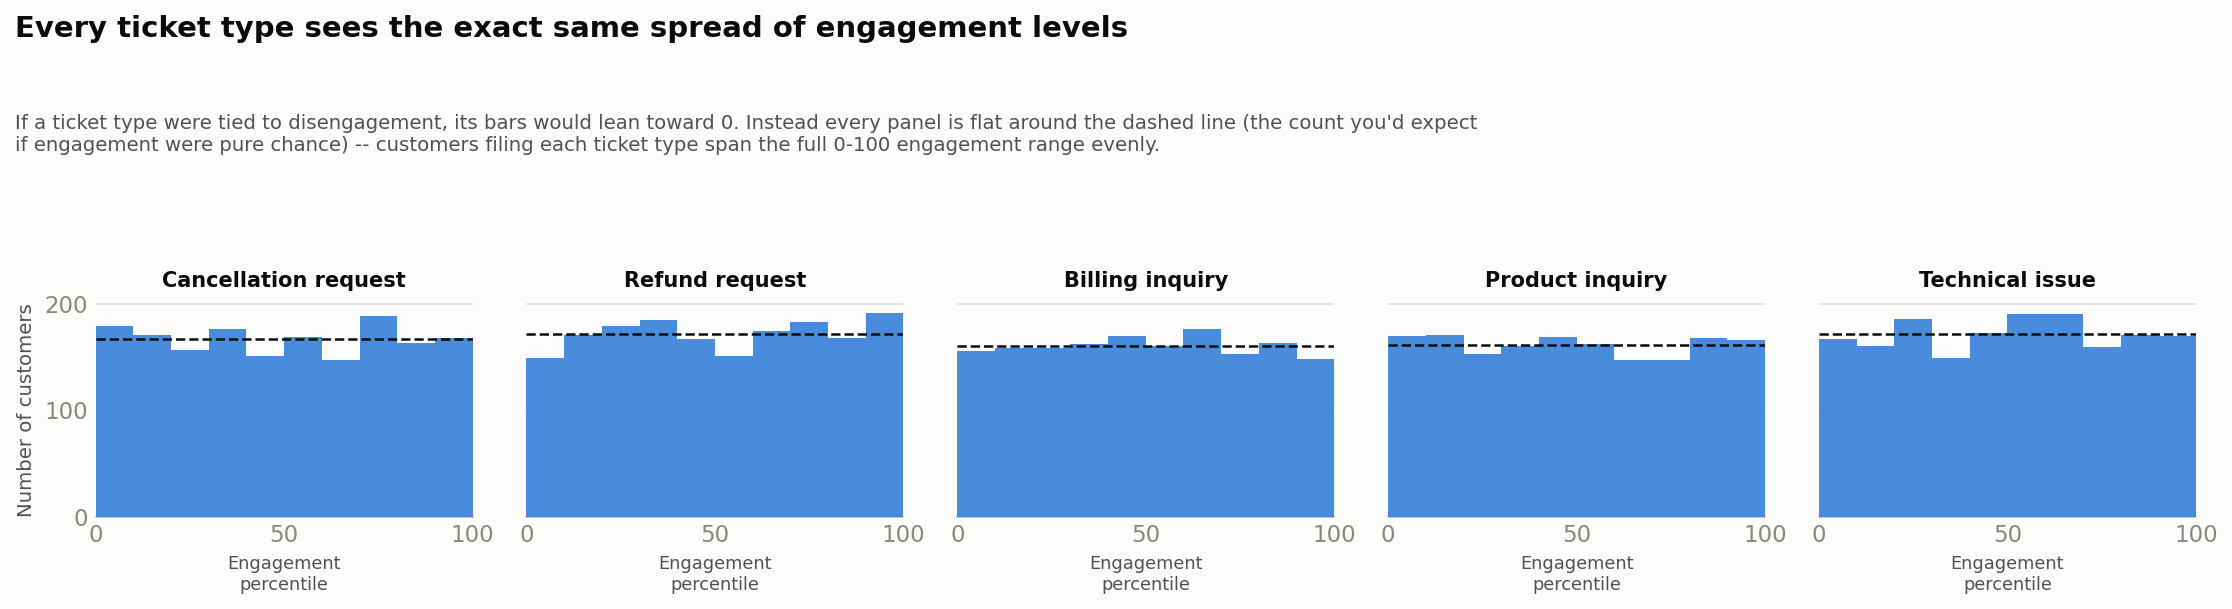

In [71]:
ticketOneRow = combined_df.drop_duplicates("Customer ID")
engagementByType = engagementDf.merge(
    ticketOneRow[["Customer ID", "Ticket Type"]], on="Customer ID", how="left"
)

ticketTypeOrder = ["Cancellation request", "Refund request", "Billing inquiry", "Product inquiry", "Technical issue"]
n_bins = 10
bin_edges = np.linspace(0, 100, n_bins + 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 3.3), dpi=150, sharey=True)

for ax, ttype in zip(axes, ticketTypeOrder):
    vals = engagementByType.loc[engagementByType["Ticket Type"] == ttype, "Engagement Percentile"]
    expected_height = len(vals) / n_bins
    ax.hist(vals, bins=bin_edges, color=SERIES_BLUE, alpha=0.85, zorder=3)
    ax.axhline(expected_height, color=INK_PRIMARY, linewidth=1.2, linestyle="--", zorder=4)
    ax.set_title(ttype, fontsize=10, color=INK_PRIMARY, fontweight="bold", pad=8)
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 50, 100])
    ax.grid(axis="y", zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    ax.set_xlabel("Engagement\npercentile", fontsize=8.5)

axes[0].set_ylabel("Number of customers", fontsize=9.5)

fig.suptitle(
    "Every ticket type sees the exact same spread of engagement levels",
    x=0.01, ha="left", fontsize=14, color=INK_PRIMARY, fontweight="bold", y=1.22,
)
fig.text(
    0.01, 1.02,
    "\n".join(textwrap.wrap(
        "If a ticket type were tied to disengagement, its bars would lean toward 0. Instead every panel is flat around the "
        "dashed line (the count you'd expect if engagement were pure chance) -- customers filing each ticket type span the "
        "full 0-100 engagement range evenly.",
        150,
    )),
    fontsize=9.5, color=INK_SECONDARY, ha="left", va="top",
)

fig.tight_layout(rect=(0, 0, 1, 0.86))
plt.show()

## 5. The same check, but for `Ticket Subject` — the more granular 16-category field

`Ticket Type` (charted above) is the coarse 5-value field. `Ticket Subject` is the finer-grained field underneath it (e.g. "Product setup," "Network problem," "Data loss") with 16 possible values. Same method as chart 4 — full distribution of `Engagement Percentile`, not just the average — applied to the more granular field, in case a coarser grouping was hiding something the finer one would catch.

It doesn't. All 16 panels below sit at roughly the same height as their own dashed reference line, in alphabetical order (not sorted by outcome, to avoid an artificial-looking gradient). Individual bins bounce around more than in the 5-category version — expected, since each subject only has ~500 customers instead of ~1,600, so there's more sampling noise per bin — but no panel shows a systematic lean toward 0 or 100. The ANOVA across all 16 subjects (already computed earlier in this notebook, cell `3d401f2e`) gives p = 0.334, confirming the visual: going more granular doesn't surface a signal that was hiding at the coarser level.

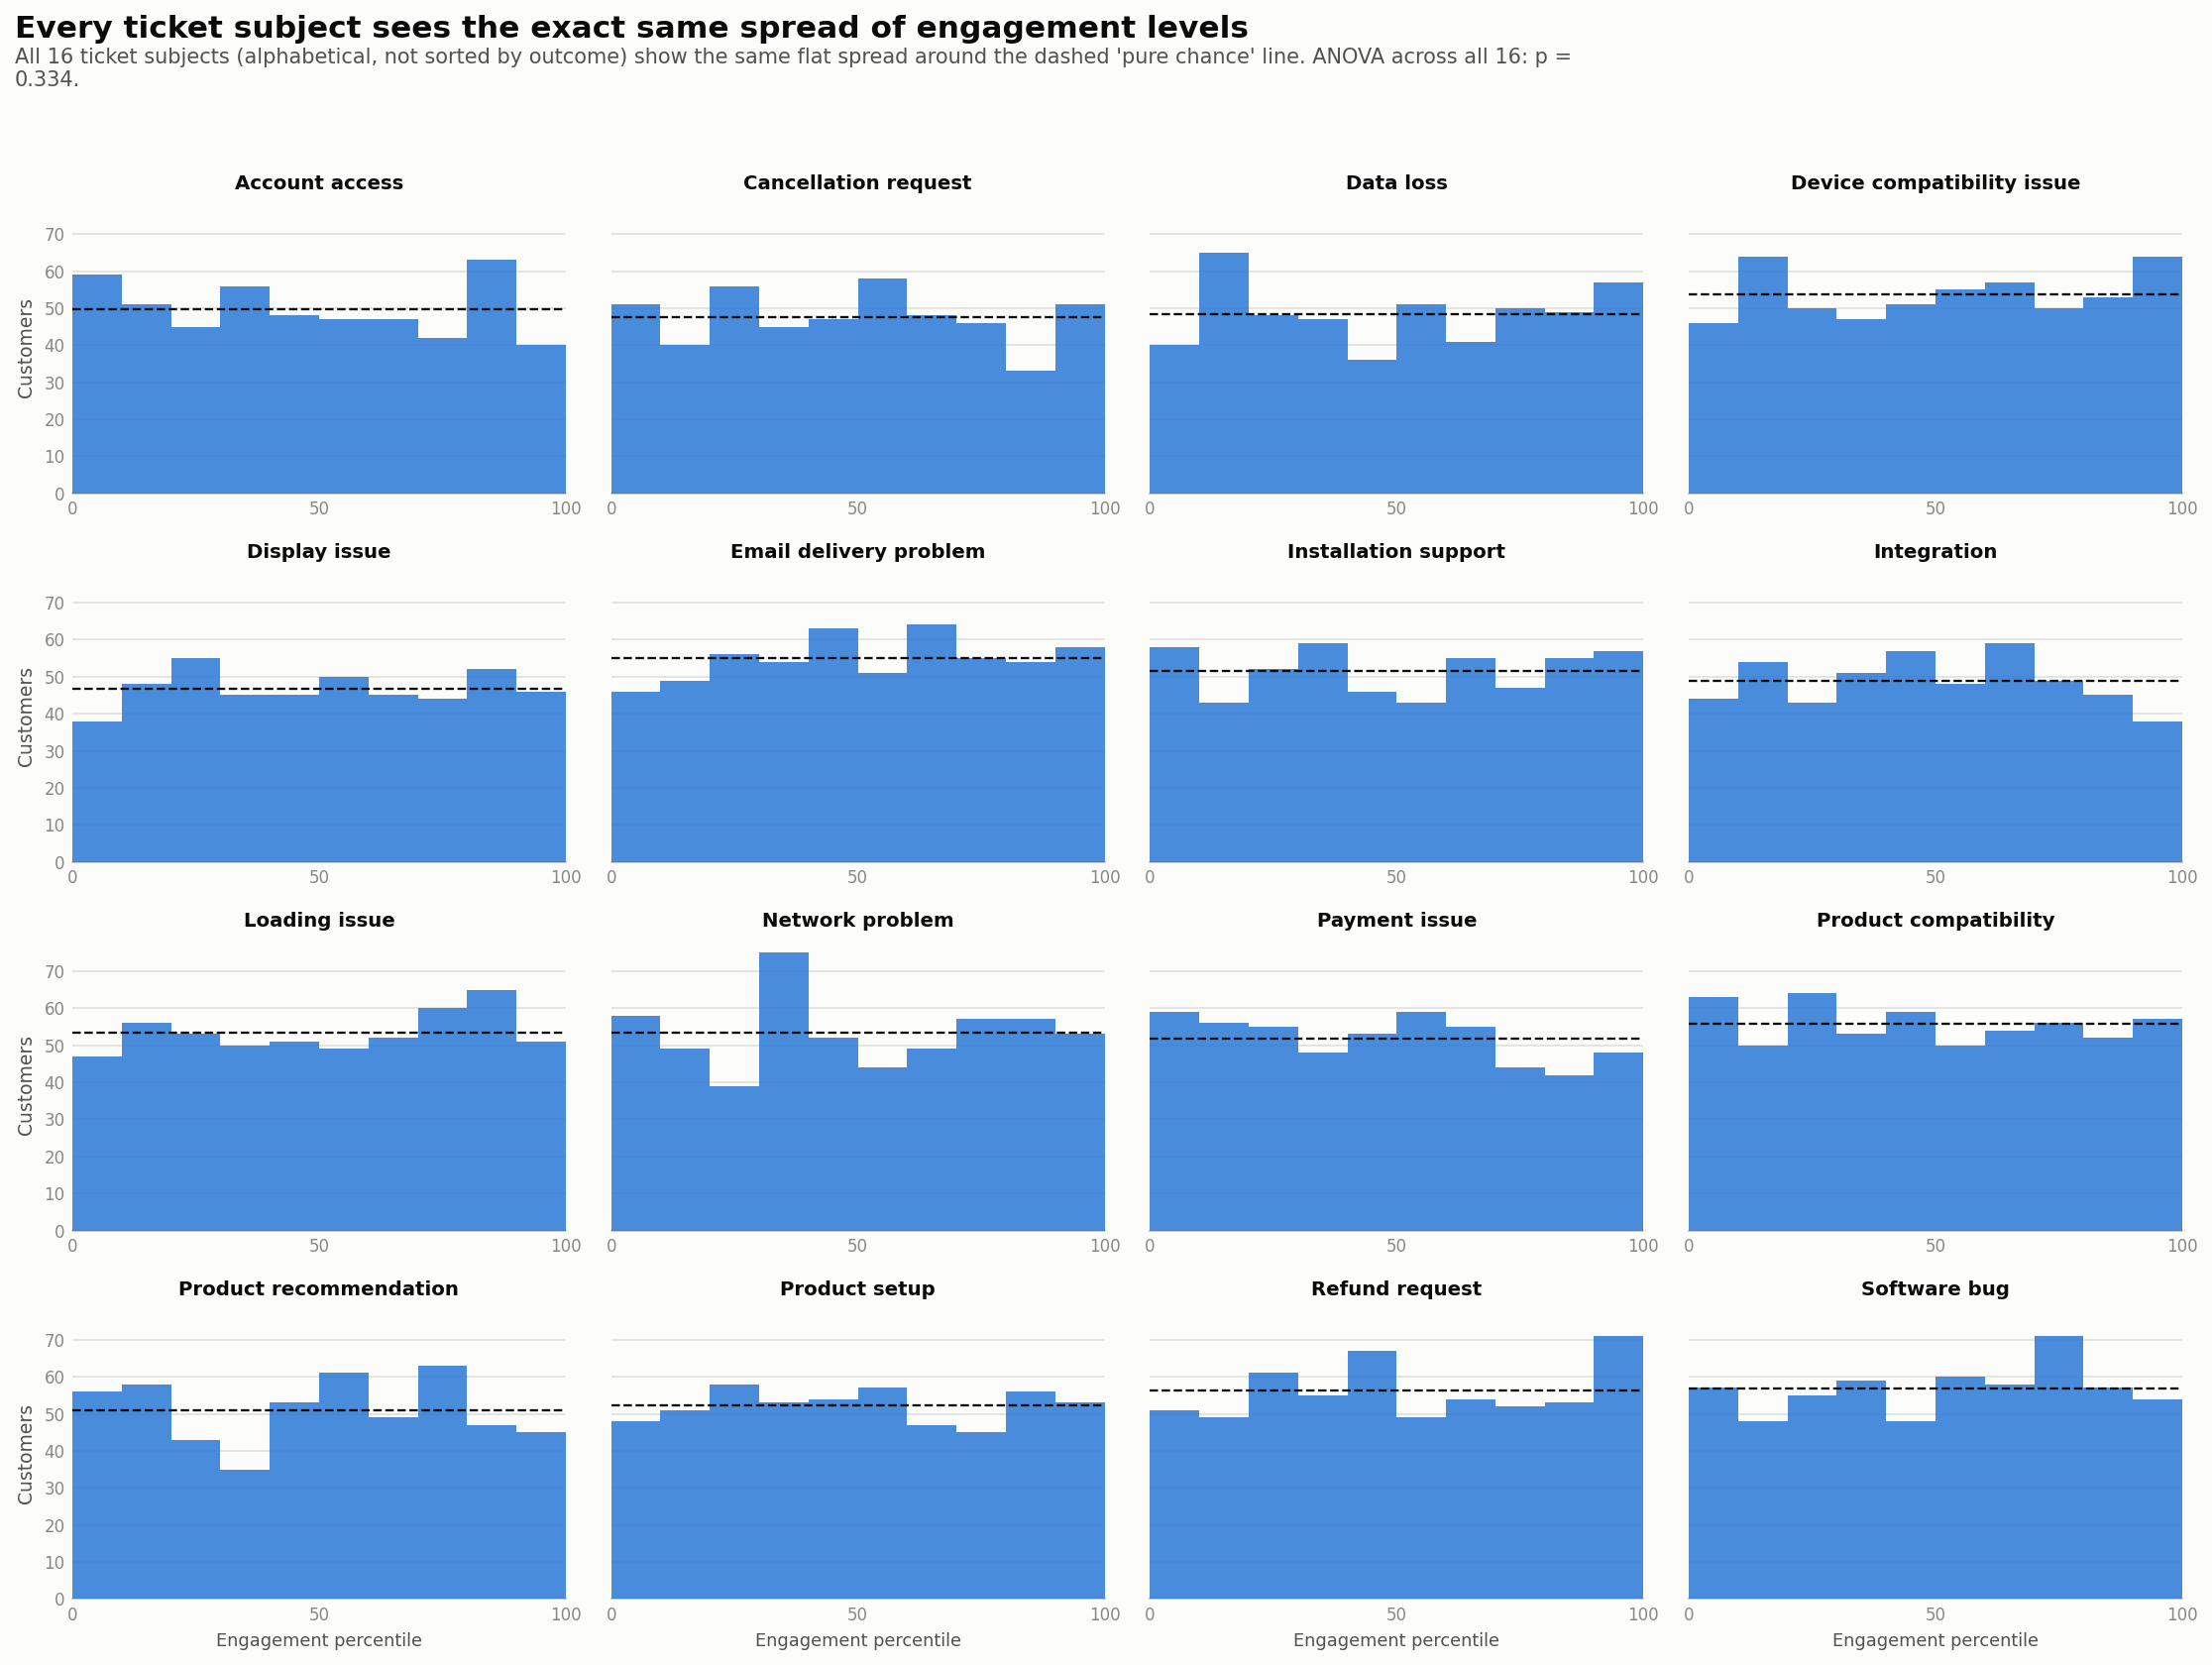

In [72]:
ticketOneRowSubject = combined_df.drop_duplicates("Customer ID")
engagementBySubject = engagementDf.merge(
    ticketOneRowSubject[["Customer ID", "Ticket Subject"]], on="Customer ID", how="left"
)

subjectOrder = sorted(engagementBySubject["Ticket Subject"].dropna().unique())
n_bins = 10
bin_edges = np.linspace(0, 100, n_bins + 1)

fig, axes = plt.subplots(4, 4, figsize=(15, 11), dpi=150, sharey=True)
axes_flat = axes.flatten()

for ax, subject in zip(axes_flat, subjectOrder):
    vals = engagementBySubject.loc[engagementBySubject["Ticket Subject"] == subject, "Engagement Percentile"]
    expected_height = len(vals) / n_bins
    ax.hist(vals, bins=bin_edges, color=SERIES_BLUE, alpha=0.85, zorder=3)
    ax.axhline(expected_height, color=INK_PRIMARY, linewidth=1.1, linestyle="--", zorder=4)
    ax.set_title(subject, fontsize=9.5, color=INK_PRIMARY, fontweight="bold", pad=6)
    ax.set_xlim(0, 100)
    ax.set_xticks([0, 50, 100])
    ax.grid(axis="y", zorder=0)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    ax.tick_params(length=0, labelsize=8)

for ax in axes_flat[len(subjectOrder):]:
    ax.axis("off")

for row in range(4):
    axes[row, 0].set_ylabel("Customers", fontsize=9)
for col in range(4):
    axes[3, col].set_xlabel("Engagement percentile", fontsize=8.5)

fig.suptitle(
    "Every ticket subject sees the exact same spread of engagement levels",
    x=0.01, ha="left", fontsize=15, color=INK_PRIMARY, fontweight="bold", y=1.015,
)
fig.text(
    0.01, 0.995,
    "\n".join(textwrap.wrap(
        "All 16 ticket subjects (alphabetical, not sorted by outcome) show the same flat spread around the dashed 'pure chance' line. "
        "ANOVA across all 16: p = 0.334.",
        150,
    )),
    fontsize=10, color=INK_SECONDARY, ha="left", va="top",
)

fig.tight_layout(rect=(0, 0, 1, 0.965))
plt.show()